In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list, add_messages]



In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from langchain_groq import ChatGroq

model = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0
)
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10c743ed0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10d1c8910>, model_name='qwen/qwen3-32b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
model.invoke("What is the capital of France?")

AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of France?" Hmm, I need to make sure I get this right. Let me think. I remember from school that France is a country in Europe, and its capital is a major city. Wait, Paris? Yeah, I think that\'s it. But wait, maybe I should double-check. Sometimes countries have different capitals, like how some people might confuse Paris with another city. Let me recall... France\'s capital is definitely Paris. I\'ve heard of Paris being called the City of Light, and it\'s known for the Eiffel Tower and the Louvre. Yeah, that\'s Paris. I don\'t think there\'s any other city that\'s the capital. Maybe some people might think Lyon or Marseille, but those are other cities in France. No, the capital is definitely Paris. I think that\'s correct. Let me just confirm in my mind. Yes, Paris is the capital of France. I can\'t think of any reason why that would be wrong. So the answer should be Paris.\n</think>\n\nThe capital of Fran

In [6]:
def superbot(state:State):
    return {"messages":[model.invoke(state['messages'])]}

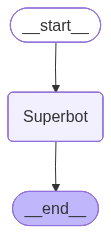

In [8]:
graph = StateGraph(State)

graph.add_node("Superbot", superbot)

graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile()

from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [9]:
graph_builder.invoke({"messages": "Hi, my name is Tejas and I like cricket."})

{'messages': [HumanMessage(content='Hi, my name is Tejas and I like cricket.', additional_kwargs={}, response_metadata={}, id='2fa0c6a8-2b13-4195-8fee-7ec7ab01afb4'),
  AIMessage(content="<think>\nOkay, the user introduced himself as Tejas and mentioned he likes cricket. I should respond in a friendly and engaging way. Let me start by greeting him and acknowledging his interest in cricket. Maybe ask him about his favorite team or player to keep the conversation going. I should keep it open-ended so he can share more. Also, make sure the tone is positive and enthusiastic. Let me check for any typos and ensure the response is natural.\n</think>\n\nHi Tejas! Nice to meet you. 🏏 Cricket is an amazing sport—do you follow any particular team or player closely? I'd love to hear what you enjoy most about the game!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 136, 'prompt_tokens': 20, 'total_tokens': 156, 'completion_time': 0.255716523, 'completion_tokens_deta

In [11]:
graph_builder.invoke({"messages": "My father purchased a new car last week. He is very happy with it. Car name is Audi A4."})
graph_builder.invoke({"messages": "He gifted this car to my mom her name is Jayshree on her 65th birthday. And today is her birthday."})
graph_builder.invoke({"messages": "I currently live in Pune. And i am from Akola natively."})

{'messages': [HumanMessage(content='I currently live in Pune. And i am from Akola natively.', additional_kwargs={}, response_metadata={}, id='5d2613e0-ce0f-457b-ab93-c7119fbf18d5'),
  AIMessage(content="<think>\nOkay, the user mentioned they live in Pune now but are originally from Akola. Let me think about how to respond appropriately.\n\nFirst, I should acknowledge both cities. Pune is a major city in Maharashtra, known for its educational institutions and tech industry. Akola is a smaller city in the same state, more rural. Maybe the user is looking for a connection or has some specific needs related to either place.\n\nI should ask how long they've been in Pune to understand their situation better. Are they a student, working professional, or something else? Also, asking about their reasons for moving could help tailor the response. Maybe they need advice on settling in Pune or missing Akola.\n\nI should also consider if they have any specific questions or need information about ei

In [13]:
graph_builder.invoke({"messages": "which car my father owns?"})

{'messages': [HumanMessage(content='which car my father owns?', additional_kwargs={}, response_metadata={}, id='c876f0a5-b4c5-4ea5-a066-53bbadc81052'),
  AIMessage(content='<think>\nOkay, the user is asking, "which car my father owns?" Let me break this down. First, I need to check if there\'s any existing information in the conversation history that mentions their father\'s car. Since this is the first message, there\'s no prior context. \n\nNext, I should consider the user\'s intent. They might be trying to find out what car their father has, maybe for practical reasons like borrowing it or just curiosity. But since I don\'t have access to personal data or their family\'s information, I can\'t provide specific details.\n\nI need to make sure I don\'t make up any information. It\'s important to be clear that I can\'t access personal data. Also, I should avoid assuming anything about their father\'s car. Maybe they want to know the make, model, or year, but without data, I can\'t help.